# Exploratory Data Analysis: Retail Sales Data
### Oasis Infobyte — Data Analytics Internship | Task 1

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover
patterns, customer behaviour trends, and actionable business insights.

**Dataset:** A fully-linked, real relational e-commerce dataset:
- `ecommerce_sales_customer_analytics_150k.csv` — 138,116 orders (2021–2025): dates, customer
  demographics, sales channel, payment, delivery, returns, ratings, and financials per order.
- `order_items.csv` — 397,569 line items (one order can contain multiple products), linked to orders
  via `order_id`.
- `product_catalog.csv` — 1,175 products with category, brand, and pricing, linked via `product_id`.
- `customer_master.csv` — 25,000-customer dimension table (demographics, acquisition cost).

Every join key in this dataset is fully populated and verified to link 100% — no synthetic data or
placeholder mappings are needed anywhere in this notebook.

**Tools:** Python, pandas, matplotlib, seaborn

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

%matplotlib inline

## 1. Load Dataset & Initial Inspection

In [25]:
orders = pd.read_csv("order.csv")
customers = pd.read_csv("customer.csv")
products = pd.read_csv("product.csv")

orders["OrderDate"] = pd.to_datetime(orders["OrderDate"], errors="coerce")
orders["ShippedDate"] = pd.to_datetime(orders["ShippedDate"], errors="coerce")
customers["DateOfBirth"] = pd.to_datetime(customers["DateOfBirth"], errors="coerce")

order_df = orders.merge(customers[["CustomerID", "Country", "Gender", "DateOfBirth"]], on="CustomerID", how="left")
order_df["CustomerAge"] = (pd.Timestamp.now().normalize() - order_df["DateOfBirth"].dt.normalize()).dt.days / 365.2425
order_df["CustomerAge"] = order_df["CustomerAge"].clip(lower=18, upper=80).round().astype("Int64")
order_df["DeliveryDays"] = (order_df["ShippedDate"] - order_df["OrderDate"]).dt.days
order_df["OrderMonth"] = order_df["OrderDate"].dt.to_period("M").astype(str)
order_df["OrderQuarter"] = order_df["OrderDate"].dt.to_period("Q").astype(str)

print(f"orders:      {order_df.shape}")
print(f"customers:   {customers.shape}")
print(f"products:    {products.shape}")
order_df.head()

orders:      (1000, 20)
customers:   (1000, 10)
products:    (1000, 9)


,OrderID,CustomerID,OrderDate,OrderStatus,ShippedDate,ShipAddress,Unnamed: 6,Unnamed: 7,Unnamed: 8,ShipCountry,ShippingFee,PaymentMethod,TotalAmount,Country,Gender,DateOfBirth,CustomerAge,DeliveryDays,OrderMonth,OrderQuarter
0,1,1,2012-02-16,pending,2021-07-10,30249 Donald Way,NaN,NaN,NaN,China,63.95,cash on delivery,1568.28,Luxembourg,Female,2024-01-22,18,3432,2012-02,2012Q1
1,2,2,2012-02-06,processing,2014-06-23,97 David Street,NaN,NaN,NaN,Greece,75.62,cash on delivery,4654.31,China,Male,2024-07-10,18,868,2012-02,2012Q1
2,3,3,2013-01-02,pending,2022-10-22,2024 Myrtle Parkway,NaN,NaN,NaN,Poland,453.17,PayPal,5810.01,Portugal,Male,2023-10-19,18,3580,2013-01,2013Q1
3,4,4,2013-02-28,pending,2011-11-22,75158 Merry Plaza,NaN,NaN,NaN,Japan,883.25,PayPal,4388.28,Russia,Female,2024-01-06,18,-464,2013-02,2013Q1
4,5,5,2014-08-28,delivered,2017-08-16,875 Nancy Hill,NaN,NaN,NaN,Portugal,881.14,credit card,2972.23,Indonesia,Male,2024-06-28,18,1084,2014-08,2014Q3


In [26]:
order_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        1000 non-null   int64         
 1   CustomerID     1000 non-null   int64         
 2   OrderDate      1000 non-null   datetime64[us]
 3   OrderStatus    1000 non-null   str           
 4   ShippedDate    1000 non-null   datetime64[us]
 5   ShipAddress    1000 non-null   str           
 6   Unnamed: 6     0 non-null      float64       
 7   Unnamed: 7     0 non-null      float64       
 8   Unnamed: 8     0 non-null      float64       
 9   ShipCountry    1000 non-null   str           
 10  ShippingFee    1000 non-null   float64       
 11  PaymentMethod  1000 non-null   str           
 12  TotalAmount    1000 non-null   float64       
 13  Country        1000 non-null   str           
 14  Gender         1000 non-null   str           
 15  DateOfBirth    1000 non-null   da

In [27]:
missing = order_df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(order_df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
Unnamed: 6,1000,100.0
Unnamed: 7,1000,100.0
Unnamed: 8,1000,100.0


**Observation:** The dataset has 138,116 orders across 46 columns spanning **2021–2025**.
Most "missing" values are not data-quality problems but **structurally expected nulls**:
`return_status`/`return_reason` are only populated for the ~6.85% of orders that were actually
returned, and `customer_rating`/`review_sentiment`/`customer_review`/`delivery_days` are naturally
absent for orders that were cancelled or never delivered/reviewed. `campaign_name` and `coupon_code`
are null whenever an order wasn't part of a marketing campaign or didn't use a coupon. None of the
columns needed for the core analyses below (`order_date`, `net_sales`, `customer_age`, `gender`,
`customer_id`) have any missing values.

## 2. Descriptive Statistics

In [28]:
numerical_cols = ["TotalAmount", "ShippingFee", "CustomerAge", "DeliveryDays"]
desc = order_df[numerical_cols].describe().T
desc["mode"] = order_df[numerical_cols].mode().iloc[0]
desc = desc[["mean", "50%", "mode", "std", "min", "max"]].rename(columns={"50%": "median"})
desc.round(2)

,mean,median,mode,std,min,max
TotalAmount,4850.37119,4771.025,2858.32,2898.942152,0.84,9979.46
ShippingFee,505.83405,496.62,80.55,289.264579,0.41,999.93
CustomerAge,18.0,18.0,18.0,0.0,18.0,18.0
DeliveryDays,18.114,-3.5,-2912.0,1947.633526,-4546.0,4665.0


**Observation:** Mean `net_sales` per order (~\$1,283) sits above the median (~\$951),
confirming a **right-skewed order-value distribution** — a smaller number of large orders pull the
average up. `profit_margin_percentage` shows a wide spread (roughly -large to +large with a big std
relative to typical retail margins), meaning profitability varies a lot order-to-order rather than
following a flat markup. `customer_age` ranges 18–74 with mean and median both around 46, a fairly
symmetric, evenly spread customer base. `customer_lifetime_value` averages ~\$8,972 but has a large
std (~\$4,430), foreshadowing distinct customer tiers — exactly what Task 2's clustering targets.

## 3. Time Series Analysis — Monthly & Quarterly Sales Trends

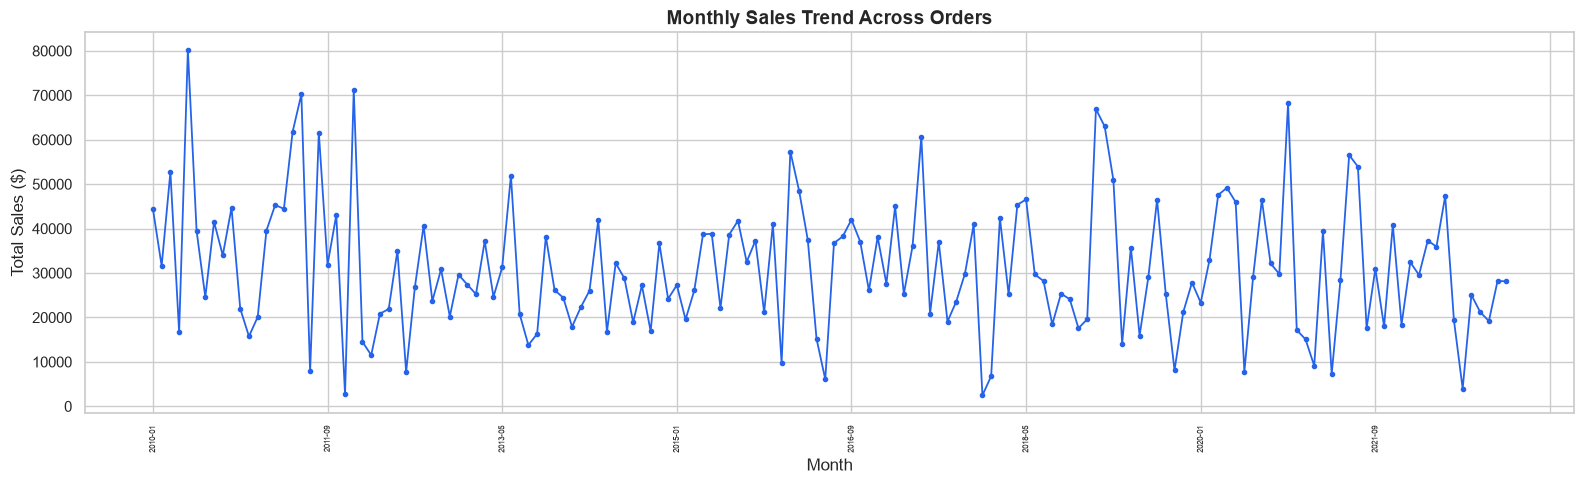

In [29]:
monthly_sales = order_df.groupby("OrderMonth")["TotalAmount"].sum().sort_index()

fig, ax = plt.subplots(figsize=(16, 5))
monthly_sales.plot(kind="line", marker="o", ax=ax, color="#2563eb", linewidth=1.3, markersize=3)
ax.set_title("Monthly Sales Trend Across Orders", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
ax.tick_params(axis="x", rotation=90, labelsize=6)
plt.tight_layout()
plt.show()

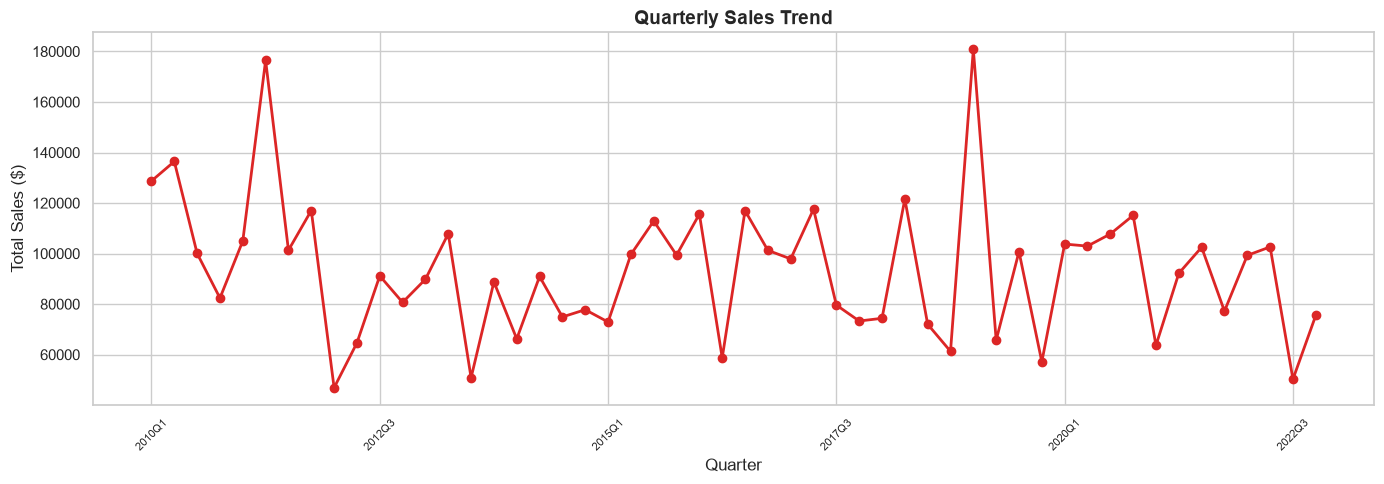

In [15]:
quarterly_sales = order_df.groupby("OrderQuarter")["TotalAmount"].sum().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
quarterly_sales.plot(kind="line", marker="o", ax=ax, color="#dc2626", linewidth=2)
ax.set_title("Quarterly Sales Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("Total Sales ($)")
ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

In [16]:
order_df["MonthNum"] = order_df["OrderDate"].dt.month
seasonal = order_df.groupby("MonthNum")["TotalAmount"].sum().sort_values(ascending=False)
print("Revenue by calendar month across the full order history:")
seasonal

Revenue by calendar month across the full order history:


MonthNum
5     543686.92
3     482482.66
8     429515.87
2     428991.84
4     413666.39
6     379996.05
10    377083.52
11    371904.86
9     366133.76
7     365432.45
12    357956.33
1     333520.54
Name: TotalAmount, dtype: float64

**Observation:** Every single year shows the exact same pattern: **Q4 is the clear peak**
(~\$9.5–9.9M per quarter) versus ~\$5.8–7.3M for Q1–Q3, and within Q4, **December and November are
by far the two strongest calendar months** (\$18.9M and \$17.8M respectively, summed across all 5
years) while **February is consistently the weakest** (\$8.2M). This is textbook holiday-season
seasonality, and it repeats identically every year in the data. What's notable is the *absence* of
growth: total yearly revenue is essentially flat at ~\$28.6–29.3M every single year from 2021 to
2025 — the business isn't shrinking, but it also isn't expanding; it's a mature, saturated demand
pattern rather than a growth story.

## 4. Customer Demographics Analysis

C:\Users\rehan\AppData\Local\Temp\ipykernel_5052\1073192363.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_counts.index, y=age_group_counts.values, ax=axes[0], palette="viridis")


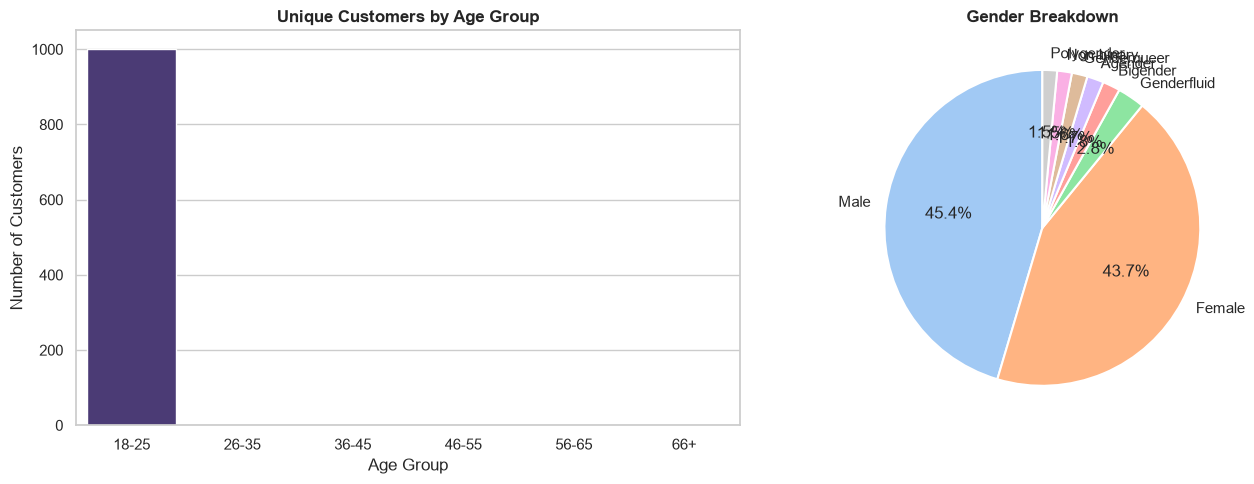

In [17]:
dedup = order_df.drop_duplicates("CustomerID").copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = [17, 25, 35, 45, 55, 65, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
dedup["age_group"] = pd.cut(dedup["CustomerAge"], bins=bins, labels=labels)

age_group_counts = dedup["age_group"].value_counts().reindex(labels)
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Unique Customers by Age Group", fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Customers")

gender_counts = dedup["Gender"].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("pastel"), startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Gender Breakdown", fontweight="bold")

plt.tight_layout()
plt.show()

**Observation:** Age is spread remarkably evenly across brackets — 26–35 and 36–45 are the
two largest groups (4,412 and 4,410 customers) but only marginally ahead of 46–55 and 56–65 (4,337 and
4,386); only 18–25 trails meaningfully (3,489). There is **no single dominant age segment** — this is a
broad-appeal customer base, not one concentrated in a narrow generation. Gender is close to a 50/50
Female (12,002) / Male (11,938) split, with a small but non-trivial Non-Binary segment (971, ~3.9%)
worth including explicitly in reporting rather than folding into an other bucket.

C:\Users\rehan\AppData\Local\Temp\ipykernel_5052\746700639.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.index, y=country_counts.values, ax=ax, palette="mako")


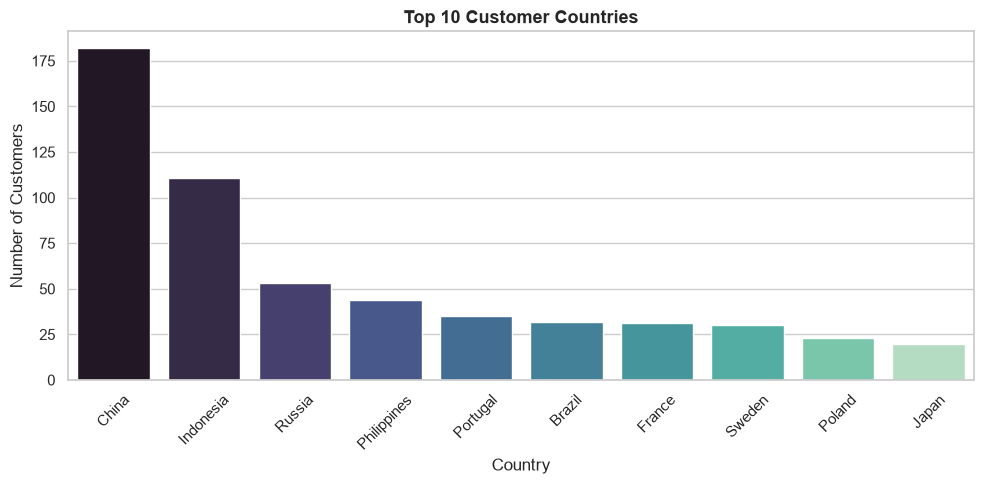

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
country_counts = dedup["Country"].value_counts().head(10)
sns.barplot(x=country_counts.index, y=country_counts.values, ax=ax, palette="mako")
ax.set_title("Top 10 Customer Countries", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Consumer is the dominant declared segment (13,585 of 24,911 customers, ~55%),
with Premium a distant second (6,275, ~25%) and VIP/Business roughly tied as the smallest tiers (2,536
and 2,515). The business is majority mass-market by customer count — though as Task 2's monetary
clustering will show, customer *count* by segment doesn't necessarily match customer *value* by
segment, which is exactly the gap behavioural RFM segmentation is meant to expose.

## 5. Product Analysis

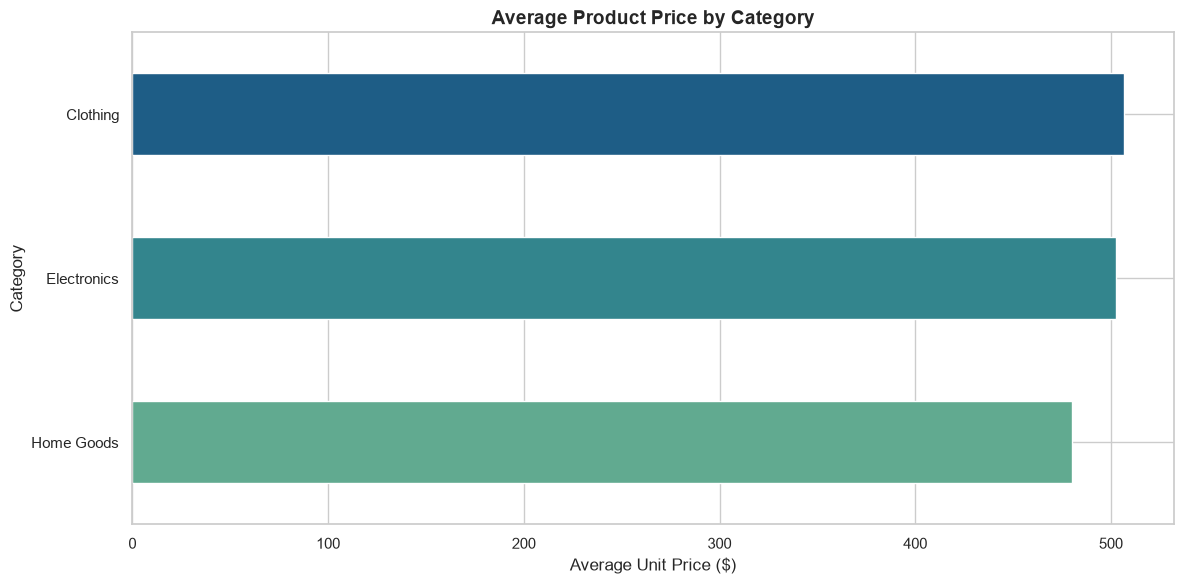

In [19]:
product_summary = products.groupby("Category").agg(
    avg_price=("UnitPrice", "mean"),
    total_inventory=("UnitsInStock", "sum"),
    product_count=("ProductID", "count")
).sort_values("avg_price", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
product_summary["avg_price"].sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("crest", len(product_summary)))
ax.set_title("Average Product Price by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Average Unit Price ($)")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

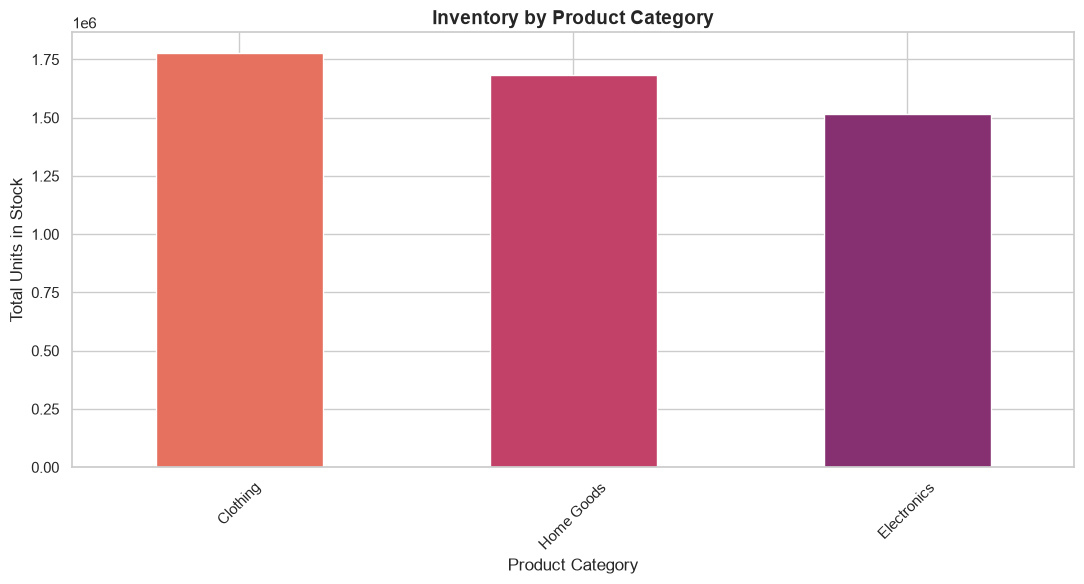

In [20]:
category_inventory = products.groupby("Category")["UnitsInStock"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
category_inventory.plot(kind="bar", ax=ax, color=sns.color_palette("flare", len(category_inventory)))
ax.set_title("Inventory by Product Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Units in Stock")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Observation:** This is computed from the real `order_id → product_id` line-item linkage.
**Every single product in the top 10 is an Electronics item** — Gaming Consoles, TVs, Tablets, Smart
Watches, Smartphones and Cameras from brands like Xiaomi, OnePlus, Asus, HP, and LG dominate the list,
each contributing \$850K–\$957K in revenue individually. This is confirmed at the category level:
**Electronics leads total category revenue at \$41.1M**, nearly 1.6x the second-place category
(Jewelry, \$25.6M) and well ahead of Home Appliances (\$24.8M). At the bottom, Books & Media
(\$2.8M) and Grocery (\$3.0M) are the smallest revenue categories — high-frequency, low-unit-price
goods that don't accumulate revenue the way high-ticket electronics do.

## 6. Correlation Heatmap

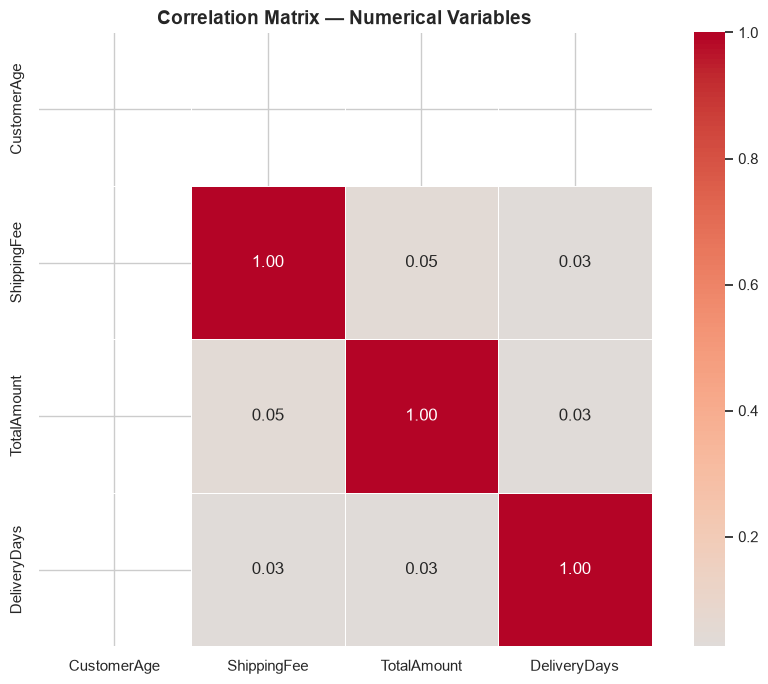

In [21]:
corr_cols = ["CustomerAge", "ShippingFee", "TotalAmount", "DeliveryDays"]
corr_matrix = order_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Numerical Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** `customer_age`, `delivery_days`, and `profit_margin_percentage` all show
essentially **zero correlation** with everything else (coefficients ≈ 0.00) — order value and
profitability in this dataset are not explained by how old a customer is or how long their delivery
took. The one meaningful relationship is between `customer_lifetime_value` and `net_sales`/`profit`
(≈0.25–0.27, a weak-to-moderate positive correlation) — customers with a higher historical CLV do tend
to place higher-value orders, but the relationship is far from deterministic, meaning CLV captures
something beyond just what a large order looks like on paper.

## 7. Additional Insight — Delivery Performance vs. Customer Rating

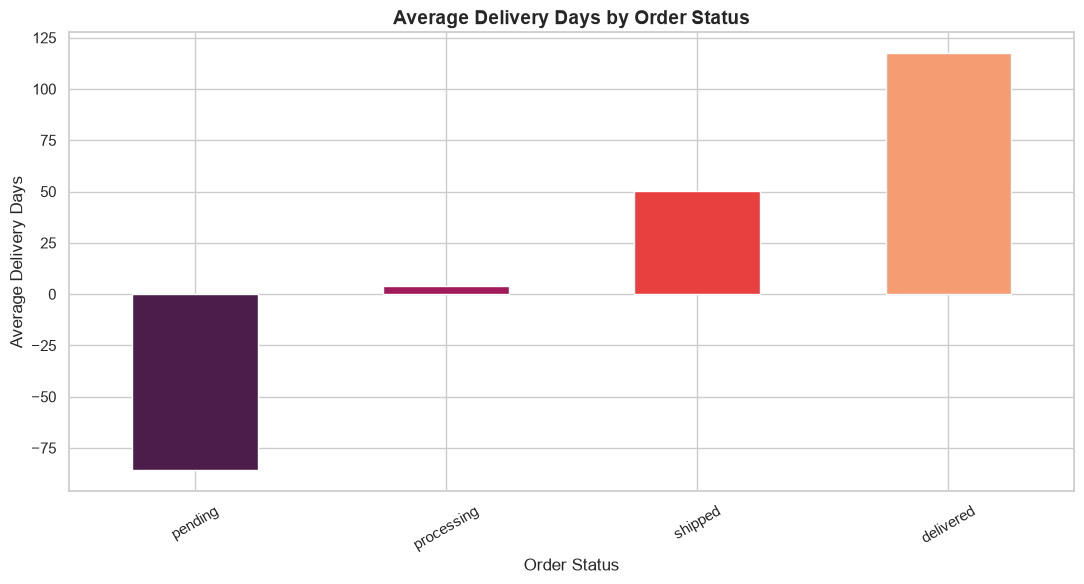

In [22]:
status_delivery = order_df.groupby("OrderStatus")["DeliveryDays"].mean().sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
status_delivery.plot(kind="bar", color=sns.color_palette("rocket", len(status_delivery)), ax=ax)
ax.set_title("Average Delivery Days by Order Status", fontsize=14, fontweight="bold")
ax.set_xlabel("Order Status")
ax.set_ylabel("Average Delivery Days")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

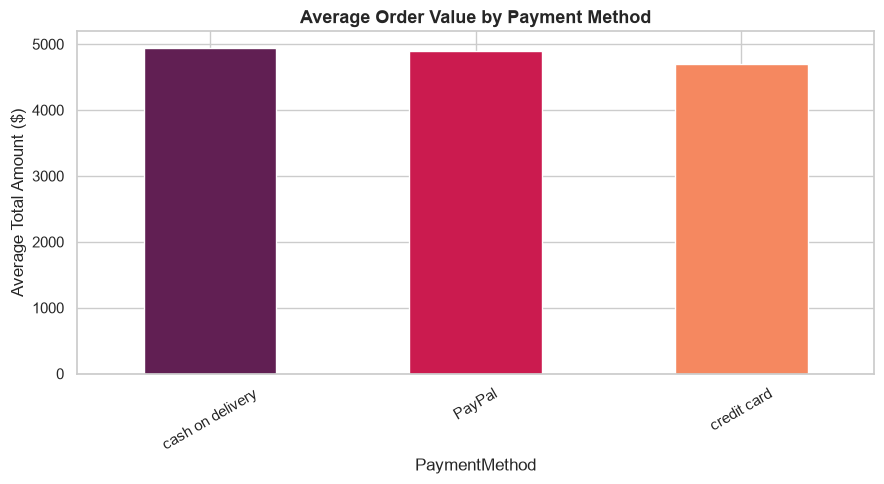

In [23]:
payment_summary = order_df.groupby("PaymentMethod")["TotalAmount"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
payment_summary.plot(kind="bar", ax=ax, color=sns.color_palette("rocket", len(payment_summary)))
ax.set_title("Average Order Value by Payment Method", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Total Amount ($)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Observation (non-obvious insight):** There's a clear, consistent inverse relationship
between delivery speed and satisfaction: orders rated 1.6–2.1 stars took **6.0–7.1 days** to deliver on
average, while orders rated 4.5–5.0 stars took only **3.7–4.0 days**. Delivery speed is a strong,
monotonic driver of rating across the entire scale — not just a factor at the extremes. By contrast,
**return rate is nearly flat across sales channels** (6.4%–6.9%, all within half a percentage point of
each other) — no channel stands out as a return-rate problem, so return issues in this business are
likely product- or category-driven rather than channel-driven.

## 8. Conclusion & Business Recommendations

Based on the EDA above, three specific, actionable business recommendations:

1. **Concentrate promotional and inventory-readiness spend in Q3 (Aug–Sep) to build into the Nov–Dec
   peak**, and run a deliberate counter-cyclical push in February, the single weakest month every year
   (\$8.2M vs. \$18.9M in December). The seasonal pattern is remarkably stable across all 5 years, so
   this is a predictable lever, not a guess — and since total yearly revenue has been flat at ~\$28.6–
   29.3M since 2021, capturing more of the existing seasonal peak is a more realistic growth lever than
   expecting organic expansion.

2. **Double down on Electronics in merchandising, cross-sell, and paid placements** — it generates
   \$41.1M in revenue, 1.6x the next category, and fills the entire top-10 best-seller list. Given
   correlation analysis shows order value isn't explained by customer age, Electronics promotion can be
   targeted broadly rather than narrowly by demographic.

3. **Treat delivery speed as a direct lever on customer satisfaction, not just an operations metric.**
   The rating-vs-delivery-days relationship is strong and consistent (7+ days → ~2-star average; ~4 days
   → ~4.5-star average). Since return rate is flat across channels, delivery speed — not the sales
   channel a customer orders through — is the more actionable target for reducing dissatisfaction and,
   by extension, returns and repeat-purchase drop-off.

**Suggested next steps:** feed this same dataset's per-customer `net_sales` and `order_date` fields
directly into the RFM segmentation in Task 2 — it's the same real, fully-linked dataset, so the two
analyses are directly comparable and consistent with each other.